<a href="https://colab.research.google.com/github/kfafa2018-ux/Computer-Vision/blob/main/PCA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction
Computer vision often deals with high dimensional data. As the dimensions of data increase so do its features (More dimensions also act as noise rather than features).
Dimensionality reduction is important in CV as it reduces the number of input variables,  making the CV algorithms faster and more efficient.
In this notebook we will explore dimensionality reduction with Principal Component Analysis and T- Distributed Stochastic Neighbourhood embedding (T-SNE).

Let's begin by loading the MNIST  (Modified National Institute of Standards and Technology) Dataset- a large database of handwritten digits that is commonly used for training various image processing systems.

Download the MNIST Dataset from https://www.kaggle.com/c/digit-recognizer/data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Functions to read and show images.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d0 = pd.read_csv('/content/drive/MyDrive/CV/Week 1/digit-recognizer/train.csv')

print(d0.head(5)) # print first five rows of d0.

# save the labels into a variable l.
l = d0['label']

# Drop the label feature and store the pixel data in d.
d = d0.drop("label",axis=1)

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [3]:
print(d.shape)
print(l.shape)

(42000, 784)
(42000,)


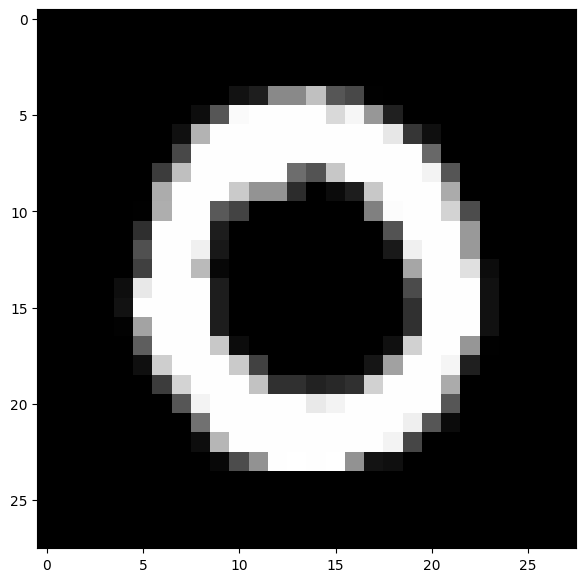

0


In [4]:
# display or plot a number.
plt.figure(figsize=(7,7))
idx = 1

grid_data = d.iloc[idx].to_numpy().reshape(28,28)  # reshape from 1d to 2d pixel array
plt.imshow(grid_data, interpolation = "none", cmap = "gray")
plt.show()

print(l[idx])

# Principal Component Analysis (PCA) for 2D visualization

Principal Component Analysis(PCA) is a linear dimension reduction algorithm. It is a projection based method that transforms the data by projecting it onto a set of orthogonal(perpendicular) axes.

Let us further explore PCA with the MNIST dataset. In this segment we are using PCA only to visualize the data.

In [5]:
# Pick first 15K data-points to work on for time-effeciency.
# Excercise: Perform the same analysis on all of 42K data-points.

labels = l.head(15000)
data = d.head(15000)

print("the shape of sample data = ", data.shape)


the shape of sample data =  (15000, 784)


In [6]:
# Data-preprocessing: Standardizing the data

from sklearn.preprocessing import StandardScaler
standardized_data = StandardScaler().fit_transform(data)
print(standardized_data.shape)


(15000, 784)


In [7]:
#find the co-variance matrix which is : A^T * A
sample_data = standardized_data

# matrix multiplication using numpy
covar_matrix = np.matmul(sample_data.T , sample_data)

print ( "The shape of variance matrix = ", covar_matrix.shape)


The shape of variance matrix =  (784, 784)


In [8]:
from scipy.linalg import eigh

# eigh function will return the eigen values in ascending order.
# To get the top 2 eigenvalues, we compute all and then select the last two.
all_values, all_vectors = eigh(covar_matrix)

# Select the two largest eigenvalues and their corresponding eigenvectors.
# values will be in ascending order, so the last two are the largest.
values = all_values[-2:]
vectors = all_vectors[:, -2:]

print("Shape of eigen vectors = ",vectors.shape)
# converting the eigen vectors into (2,d) shape for easyness of further computations.
# Transpose vectors so that each row is an eigenvector
vectors = vectors.T

print("Updated shape of eigen vectors = ",vectors.shape)
# here the vectors[1] represent the eigen vector corresponding 1st principal eigen vector.
# here the vectors[0] represent the eigen vector corresponding 2nd principal eigen vector.

Shape of eigen vectors =  (784, 2)
Updated shape of eigen vectors =  (2, 784)


In [9]:
# projecting the original data sample on the plane.
# formed by two principal eigen vectors by vector-vector multiplication.

import matplotlib.pyplot as plt
new_coordinates = np.matmul(vectors, sample_data.T)

print (" resultanat new data points' shape ", vectors.shape, "X", sample_data.T.shape," = ", new_coordinates.shape)

 resultanat new data points' shape  (2, 784) X (784, 15000)  =  (2, 15000)


In [10]:
import pandas as pd

# appending label to the 2d projected data.
new_coordinates = np.vstack((new_coordinates, labels)).T

# creating a new data frame for ploting the labeled points.
dataframe = pd.DataFrame(data=new_coordinates, columns=("1st_principal", "2nd_principal", "label"))
print(dataframe.head())

   1st_principal  2nd_principal  label
0      -5.558661      -5.043558    1.0
1       6.193635      19.305278    0.0
2      -1.909878      -7.678775    1.0
3       5.525748      -0.464845    4.0
4       6.366527      26.644289    0.0


In [11]:
import pandas as pd
df=pd.DataFrame()
df['1st']=[-5.558661,-5.043558,6.193635 ,19.305278]
df['2nd']=[-1.558661,-2.043558,2.193635 ,9.305278]
df['label']=[1,2,3,4]

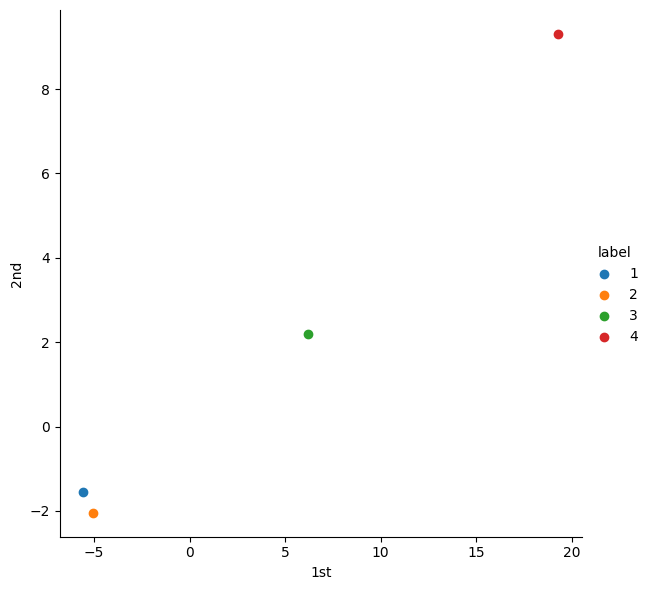

In [12]:
import seaborn as sn
import matplotlib.pyplot as plt
sn.FacetGrid(df, hue="label", height=6).map(plt.scatter, '1st', '2nd').add_legend()
plt.show()

<Axes: xlabel='1st', ylabel='2nd'>

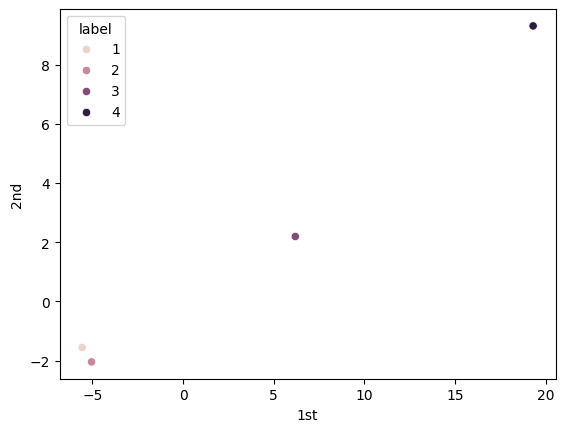

In [13]:
sn.scatterplot(x="1st",y="2nd",hue="label",data=df)

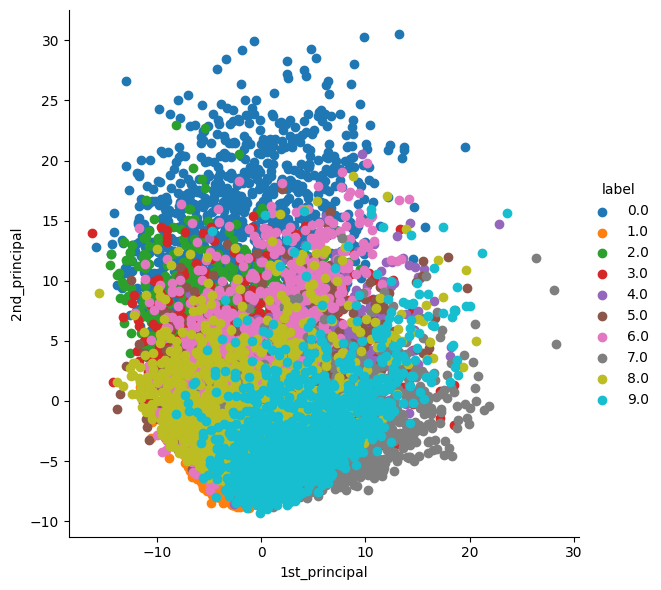

In [14]:
# ploting the 2d data points with seaborn
import seaborn as sn
sn.FacetGrid(dataframe, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

<Axes: xlabel='1st_principal', ylabel='2nd_principal'>

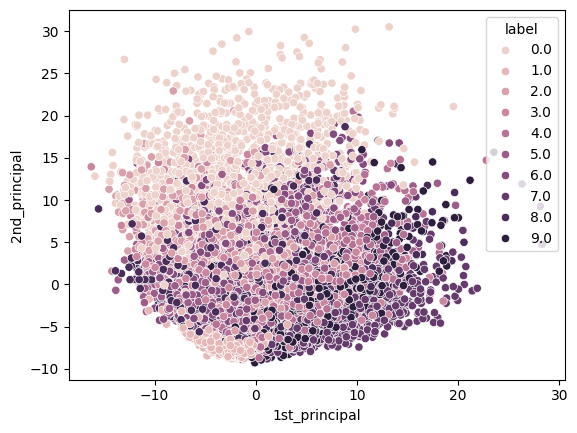

In [15]:
sn.scatterplot(x="1st_principal",y="2nd_principal",legend="full",hue="label",data=dataframe)

# PCA using Scikit-Learn

In [16]:
# initializing the pca
from sklearn import decomposition
pca = decomposition.PCA()


In [17]:
# configuring the parameteres.
# the number of components = 2
pca.n_components = 2
pca_data = pca.fit_transform(sample_data)

# pca_reduced will contain the 2-d projects of simple data.
print("shape of pca_reduced.shape = ", pca_data.shape)



shape of pca_reduced.shape =  (15000, 2)


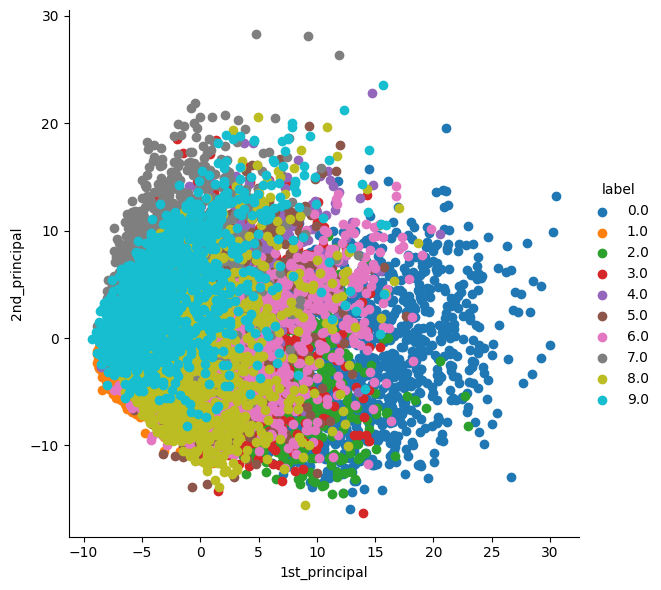

In [18]:
# attaching the label for each 2-d data point
# Re-transform sample_data to get the 2-component PCA data fresh
pca_components_2d = pca.transform(sample_data)
pca_data_with_labels = np.vstack((pca_components_2d.T, labels)).T

# creating a new data fram which help us in ploting the result data
pca_df = pd.DataFrame(data=pca_data_with_labels, columns=("1st_principal", "2nd_principal", "label"))
sn.FacetGrid(pca_df, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

# PCA for dimensionality redcution (not for visualization)
PCA creates new variables by combining the original variables in such a way that the variance is maximized.

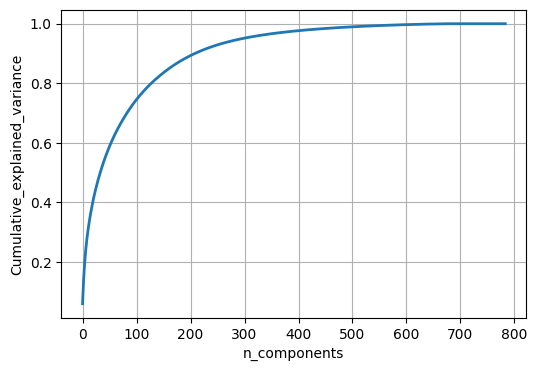

In [19]:
# PCA for dimensionality redcution (non-visualization)

pca.n_components = 784
pca_data = pca.fit_transform(sample_data)

percentage_var_explained = pca.explained_variance_ / np.sum(pca.explained_variance_);

cum_var_explained = np.cumsum(percentage_var_explained)

# Plot the PCA spectrum
plt.figure(1, figsize=(6, 4))

plt.clf()
plt.plot(cum_var_explained, linewidth=2)
plt.axis('tight')
plt.grid()
plt.xlabel('n_components')
plt.ylabel('Cumulative_explained_variance')
plt.show()


# If we take 200-dimensions, approx. 90% of variance is expalined.

# t-SNE using Scikit-Learn
t-SNE is a nonlinear dimensionality reduction technique that is well suited for embedding high dimension data into lower dimensional data (2D or 3D) for data visualization. While PCA works on retaining only global variance, t-SNE works on retaining local variance- a shortfall of PCA.


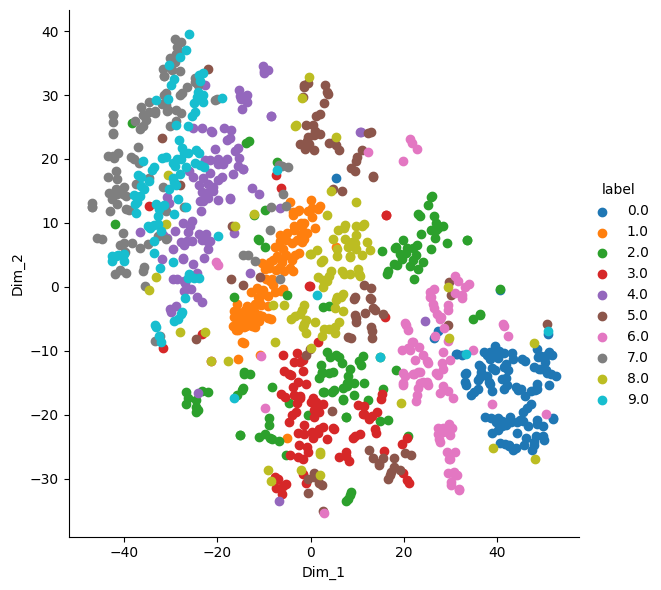

In [20]:
# TSNE

from sklearn.manifold import TSNE

# Picking the top 1000 points as TSNE takes a lot of time for 15K points
data_1000 = standardized_data[0:1000,:]
labels_1000 = labels[0:1000]

model = TSNE(n_components=2, random_state=0)
# configuring the parameteres
# the number of components = 2
# default perplexity = 30
# default learning rate = 200
# default Maximum number of iterations for the optimization = 1000

tsne_data = model.fit_transform(data_1000)


# creating a new data frame which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.show()

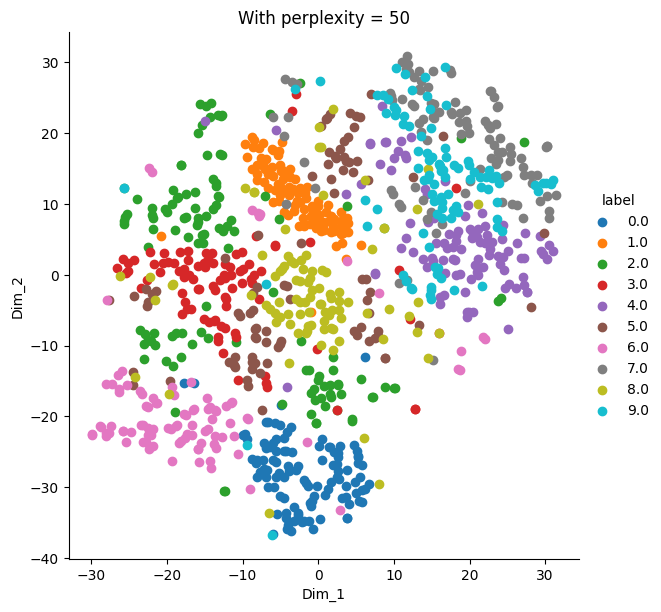

In [21]:
model = TSNE(n_components=2, random_state=0, perplexity=50)
tsne_data = model.fit_transform(data_1000)

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 50')
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


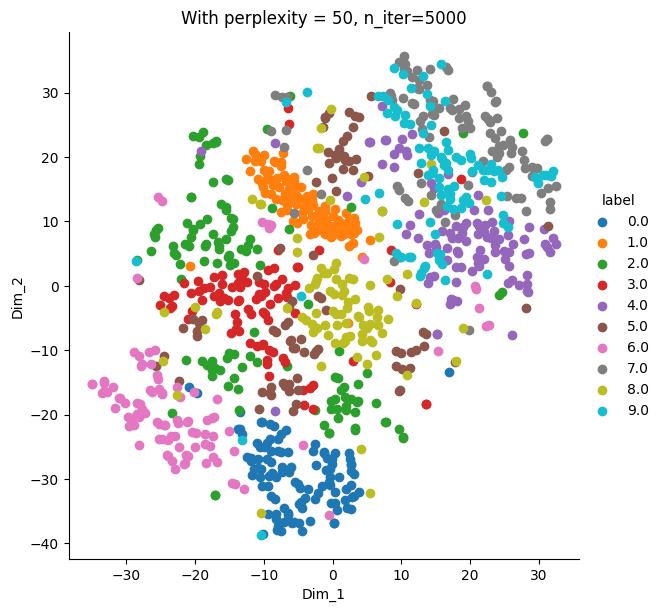

In [22]:
model = TSNE(n_components=2, random_state=0, perplexity=50,  n_iter=5000)
tsne_data = model.fit_transform(data_1000)

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 50, n_iter=5000')
plt.show()

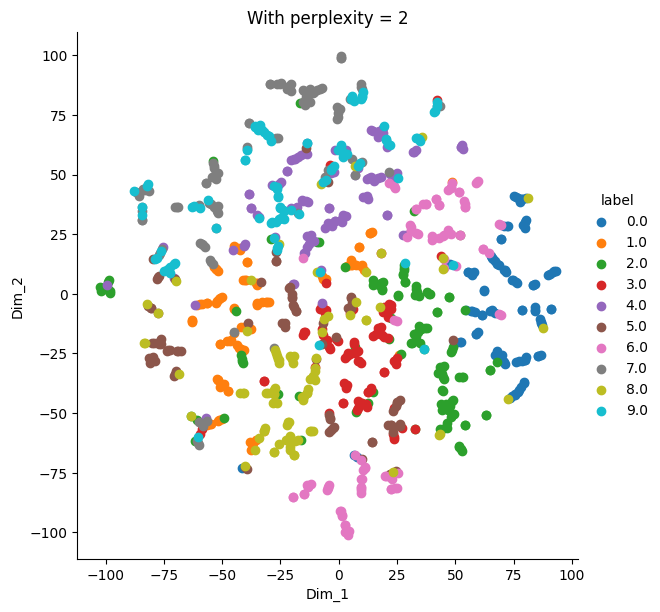

In [23]:
model = TSNE(n_components=2, random_state=0, perplexity=2)
tsne_data = model.fit_transform(data_1000)

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 2')
plt.show()

In [24]:
# Assignment

## t-SNE Analysis on Full 42,000 Data Points

In [26]:
# Use all 42K data points
full_labels = l
full_data = d

print("Shape of full data:", full_data.shape)
print("Shape of full labels:", full_labels.shape)

Shape of full data: (42000, 784)
Shape of full labels: (42000,)


### Standardizing the Full Dataset

In [27]:
from sklearn.preprocessing import StandardScaler

# Standardize the full dataset
standardized_full_data = StandardScaler().fit_transform(full_data)

print("Shape of standardized full data:", standardized_full_data.shape)

Shape of standardized full data: (42000, 784)


### t-SNE with perplexity = 30, n_iter = 1000 (default values)

Running t-SNE with perplexity=30, n_iter=1000...
t-SNE completed in 1002.88 seconds


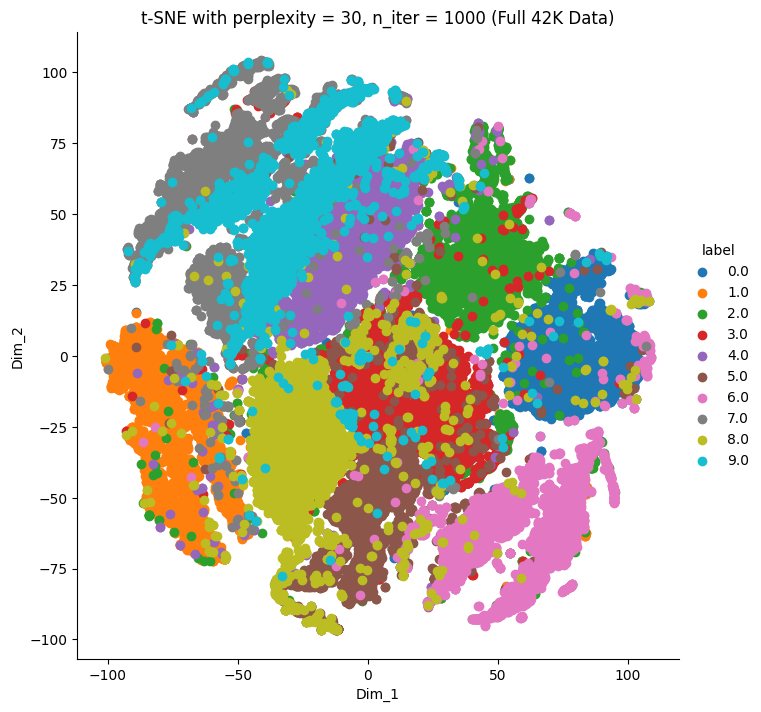

In [28]:
from sklearn.manifold import TSNE
import seaborn as sn
import matplotlib.pyplot as plt
import time

# For 42K points, t-SNE can take a very long time.
# Consider using a smaller subset or a different initialization for faster results.
# For demonstration, we will run with default parameters first.

print("Running t-SNE with perplexity=30, n_iter=1000...")
t0 = time.time()
model_tsne_default = TSNE(n_components=2, random_state=0)
tsne_data_default = model_tsne_default.fit_transform(standardized_full_data)
t1 = time.time()
print(f"t-SNE completed in {t1-t0:.2f} seconds")

# Creating a new data frame for plotting the result data
tsne_data_with_labels_default = np.vstack((tsne_data_default.T, full_labels)).T
tsne_df_default = pd.DataFrame(data=tsne_data_with_labels_default, columns=("Dim_1", "Dim_2", "label"))

# Plotting the result of t-SNE
sn.FacetGrid(tsne_df_default, hue="label", height=7).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('t-SNE with perplexity = 30, n_iter = 1000 (Full 42K Data)')
plt.show()

### t-SNE with perplexity = 50, n_iter = 5000

In [ ]:
print("Running t-SNE with perplexity=50, n_iter=5000...")
t0 = time.time()
model_tsne_50_5000 = TSNE(n_components=2, random_state=0, perplexity=50, max_iter=5000) # Changed n_iter to max_iter
tsne_data_50_5000 = model_tsne_50_5000.fit_transform(standardized_full_data)
t1 = time.time()
print(f"t-SNE completed in {t1-t0:.2f} seconds")

# Creating a new data frame for plotting the result data
tsne_data_with_labels_50_5000 = np.vstack((tsne_data_50_5000.T, full_labels)).T
tsne_df_50_5000 = pd.DataFrame(data=tsne_data_with_labels_50_5000, columns=("Dim_1", "Dim_2", "label"))

# Plotting the result of t-SNE
sn.FacetGrid(tsne_df_50_5000, hue="label", height=7).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('t-SNE with perplexity = 50, n_iter = 5000 (Full 42K Data)')
plt.show()

Running t-SNE with perplexity=50, n_iter=5000...


### t-SNE with perplexity = 5, n_iter = 1000

In [ ]:
print("Running t-SNE with perplexity=5, n_iter=1000...")
t0 = time.time()
model_tsne_5_1000 = TSNE(n_components=2, random_state=0, perplexity=5, max_iter=1000) # Changed n_iter to max_iter
tsne_data_5_1000 = model_tsne_5_1000.fit_transform(standardized_full_data)
t1 = time.time()
print(f"t-SNE completed in {t1-t0:.2f} seconds")

# Creating a new data frame for plotting the result data
tsne_data_with_labels_5_1000 = np.vstack((tsne_data_5_1000.T, full_labels)).T
tsne_df_5_1000 = pd.DataFrame(data=tsne_data_with_labels_5_1000, columns=("Dim_1", "Dim_2", "label"))

# Plotting the result of t-SNE
sn.FacetGrid(tsne_df_5_1000, hue="label", height=7).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('t-SNE with perplexity = 5, n_iter = 1000 (Full 42K Data)')
plt.show()

In [25]:
Run the same analysis using 42K points with various
#values of perplexity and iterations.

# If you use all of the points, you can expect plots like this blog below:
# http://colah.github.io/posts/2014-10-Visualizing-MNIST/

SyntaxError: invalid decimal literal (4113319347.py, line 1)